In [17]:
import pandas as pd

# Load the CSV
df = pd.read_csv('Allindiariceproduction.csv')

# Separate Area, Production, and Yield columns
area_cols = [c for c in df.columns if c.startswith('Area-')]
prod_cols = [c for c in df.columns if c.startswith('Production-')]
yield_cols = [c for c in df.columns if c.startswith('Yield-')]

# Extract the year part (e.g. "1966-67") from column names
years = [c.replace('Area-', '') for c in area_cols]

# Season-to-date mapping
season_date_map = {
    'Kharif':  '01-06',   # June  1st (Kharif sowing)
    'Rabi':    '01-11',   # Nov   1st (Rabi sowing)
    'Zaid':    '01-03',   # Mar   1st (Zaid/Summer)
    'Whole Year': '01-01',
    'Annual':  '01-01',
}

def make_date_label(year_str, season):
    """
    year_str : e.g. '2008-09'  →  start year = 2008
    season   : e.g. 'Kharif'
    returns  : '01-06-2008'
    """
    start_year = year_str.split('-')[0]          # '2008'
    mm_dd = season_date_map.get(season, '01-01') # '06-01'
    return f"{mm_dd}-{start_year}"     # '01-06-2008'

# Melt Area, Production, Yield separately, then merge
id_vars = ['Crop', 'Season']

area_long = df[id_vars + area_cols].melt(
    id_vars=id_vars, value_vars=area_cols,
    var_name='_col', value_name='Area'
)
area_long['year_str'] = area_long['_col'].str.replace('Area-', '', regex=False)

prod_long = df[id_vars + prod_cols].melt(
    id_vars=id_vars, value_vars=prod_cols,
    var_name='_col', value_name='Production'
)
prod_long['year_str'] = prod_long['_col'].str.replace('Production-', '', regex=False)

yield_long = df[id_vars + yield_cols].melt(
    id_vars=id_vars, value_vars=yield_cols,
    var_name='_col', value_name='Yield'
)
yield_long['year_str'] = yield_long['_col'].str.replace('Yield-', '', regex=False)

# Merge all three on Crop, Season, year_str
long_df = (
    area_long[['Crop', 'Season', 'year_str', 'Area']]
    .merge(prod_long[['Crop', 'Season', 'year_str', 'Production']], on=id_vars + ['year_str'])
    .merge(yield_long[['Crop', 'Season', 'year_str', 'Yield']],      on=id_vars + ['year_str'])
)

# Build the formatted 'year' label  e.g. '01-06-2008--Kharif'
long_df['year'] = long_df.apply(
    lambda r: make_date_label(r['year_str'], r['Season']), axis=1
)

# Keep only the 4 required columns (drop Crop/Season/year_str if not needed)
result = long_df[['year', 'Area', 'Production', 'Yield']].reset_index(drop=True)

print(result.head(10))
# result.to_csv('long_format_output.csv', index=False)

         year   Area  Production  Yield
0  01-06-1966  33.93       28.62    843
1  01-11-1966   1.32        1.82   1378
2  01-06-1967  34.91       35.31   1011
3  01-11-1967   1.52        2.30   1508
4  01-06-1968  35.31       37.13   1052
5  01-11-1968   1.66        2.63   1586
6  01-06-1969  35.82       37.59   1050
7  01-11-1969   1.85        2.84   1533
8  01-06-1970  35.95       39.56   1100
9  01-11-1970   1.64        2.67   1630


In [7]:
result.to_csv('long_format_output.csv', index=False)

In [19]:
# Extract year from the date string and aggregate
result['Year'] = result['year'].str.split('-').str[-1].astype(int)

yearly = result.groupby('Year', sort=True).agg(
    Area=('Area', 'sum'),
    Production=('Production', 'sum'),
    _area=('Area', 'sum'),
    _prod=('Production', 'sum'),
    Yield=('Yield', 'max')
).reset_index()

yearly = yearly.drop(columns=['_area', '_prod'])

print(yearly.head(10))

   Year   Area  Production  Yield
0  1966  35.25       30.44   1378
1  1967  36.43       37.61   1508
2  1968  36.97       39.76   1586
3  1969  37.67       40.43   1533
4  1970  37.59       42.23   1630
5  1971  37.76       43.07   1841
6  1972  36.69       39.24   1811
7  1973  38.29       44.05   1750
8  1974  37.89       39.58   1892
9  1975  39.47       48.74   1964


In [27]:
yearly.to_csv('Yearlydata.csv', index=False)

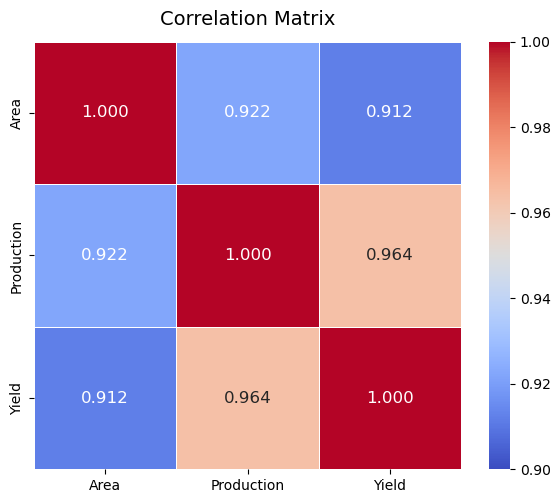

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

corr = pd.DataFrame({
    'Area':       [1.000, 0.922, 0.912],
    'Production': [0.922, 1.000, 0.964],
    'Yield':      [0.912, 0.964, 1.000]
}, index=['Area', 'Production', 'Yield'])

plt.figure(figsize=(6, 5))
sns.heatmap(
    corr,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    vmin=0.9, vmax=1.0,
    linewidths=0.5,
    square=True,
    annot_kws={'size': 12}
)
plt.title('Correlation Matrix', fontsize=14, pad=12)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

### FAO Stat data


In [33]:
import pandas as pd

df = pd.read_csv('FAOSTAT.csv')

# ── Drop Unit column ──────────────────────────────────────────────────────────
df = df.drop(columns=['Unit'])

# ── Pivot: rows=Year, columns=Element, values=Value ──────────────────────────
df_pivot = df.pivot_table(index=['Year', 'Area'], columns='Element', values='Value').reset_index()
df_pivot.columns.name = None

# ── Rename columns ────────────────────────────────────────────────────────────
df_pivot = df_pivot.rename(columns={
    'Area harvested': 'Area',
    'Area':           'Country',        # the country column was named 'Area' in raw data
    'Production':     'Production',
    'Yield':          'Yield'
})

# ── Set Year as index ─────────────────────────────────────────────────────────
df_pivot = df_pivot.set_index('Year')

# ── Divide Area and Production by 1,000,000 → Million tonnes / Million ha ────
df_pivot['Area']       = (df_pivot['Area']       / 1_000_000).round(3)
df_pivot['Production'] = (df_pivot['Production'] / 1_000_000).round(3)

print(df_pivot.head(12))


     Country    Area  Production   Yield
Year                                    
1961   China  27.045      56.218  2078.7
1961   India  34.694      53.494  1541.9
1961   Japan   3.312      16.160  4879.4
1962   China  27.711      65.675  2370.0
1962   India  35.695      49.826  1395.9
1962   Japan   3.295      16.927  5137.2
1963   China  28.487      76.439  2683.3
1963   India  35.809      55.497  1549.8
1963   Japan   3.276      16.649  5082.1
1964   China  30.349      85.854  2828.9
1964   India  36.462      58.962  1617.1
1964   Japan   3.264      16.356  5011.1


In [35]:
df_pivot = df_pivot[df_pivot['Country'] != 'Japan']
df_pivot.to_csv('FAOSTAT_clean1.csv')

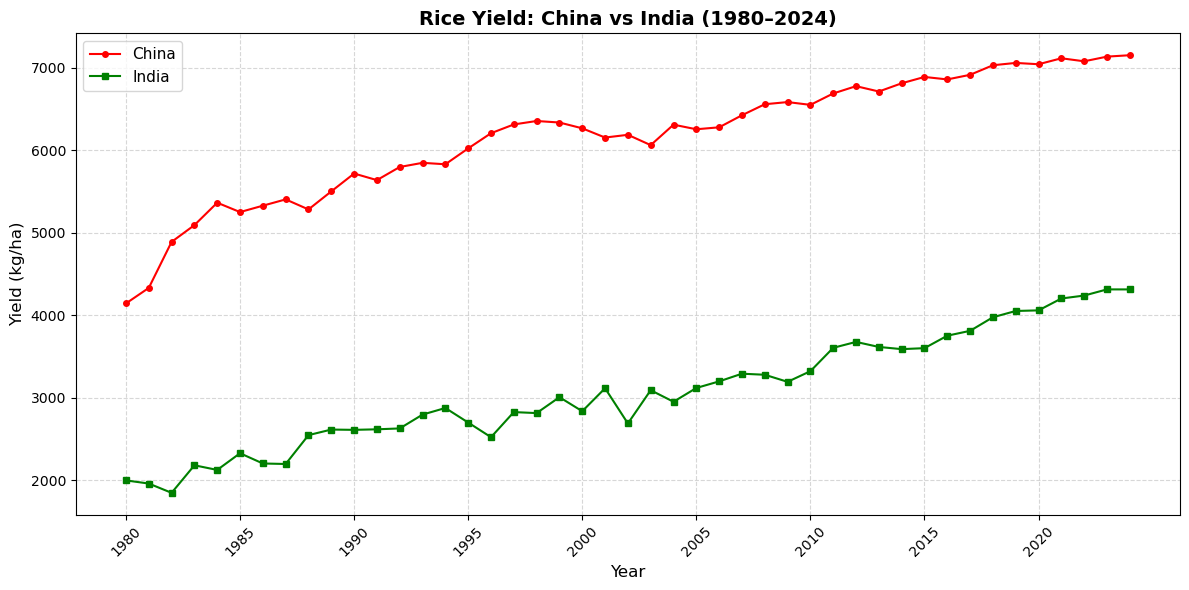

In [37]:
import matplotlib.pyplot as plt

# Filter from 1980 onwards, China and India only
plot_df = df_pivot[(df_pivot['Country'].isin(['China', 'India'])) & (df_pivot.index >= 1980)]

china = plot_df[plot_df['Country'] == 'China']
india = plot_df[plot_df['Country'] == 'India']

plt.figure(figsize=(12, 6))
plt.plot(china.index, china['Yield'], marker='o', markersize=4, label='China', color='red')
plt.plot(india.index, india['Yield'], marker='s', markersize=4, label='India', color='green')

plt.title('Rice Yield: China vs India (1980–2024)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Yield (kg/ha)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(range(1980, 2025, 5), rotation=45)
plt.tight_layout()
plt.savefig('yield_china_india.png', dpi=150)
plt.show()

In [41]:
print(len(years))                       # should match
print(len(china['Production'].values))
print(len(india['Production'].values))

60
45
45


years: 4, china: 4, india: 4


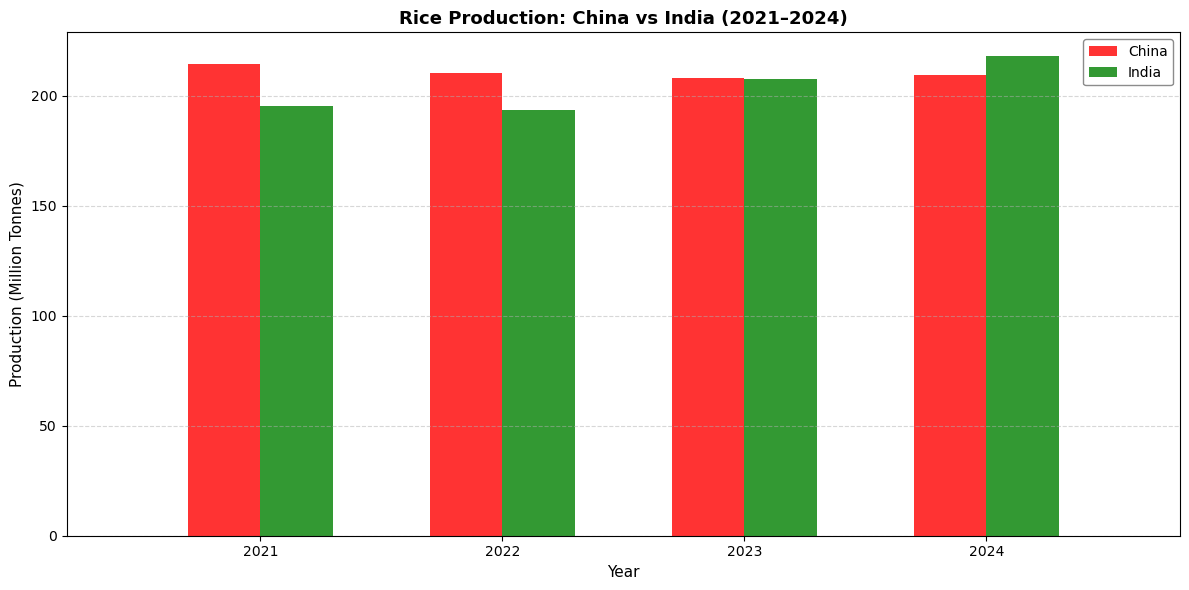

In [45]:
plot_df = df_pivot[(df_pivot['Country'].isin(['China', 'India'])) & (df_pivot.index >= 2021)]
china   = plot_df[plot_df['Country'] == 'China']
india   = plot_df[plot_df['Country'] == 'India']
years   = sorted(china.index.unique())   # ← use china/india index, not plot_df

print(f"years: {len(years)}, china: {len(china)}, india: {len(india)}")  # should be 4, 4, 4

width = 0.15
x = np.arange(len(years)) * 0.5

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width/2, china['Production'].values, width, label='China', color='red',   alpha=0.8)
ax.bar(x + width/2, india['Production'].values, width, label='India', color='green', alpha=0.8)

ax.set_xlim(-0.4, x[-1] + 0.4)
ax.set_title('Rice Production: China vs India (2021–2024)', fontsize=13, fontweight='bold')
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Production (Million Tonnes)', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(years)
ax.legend(fontsize=10, loc='upper right', frameon=True, framealpha=0.9, edgecolor='gray')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('production_bar_china_india.png', dpi=150)
plt.show()

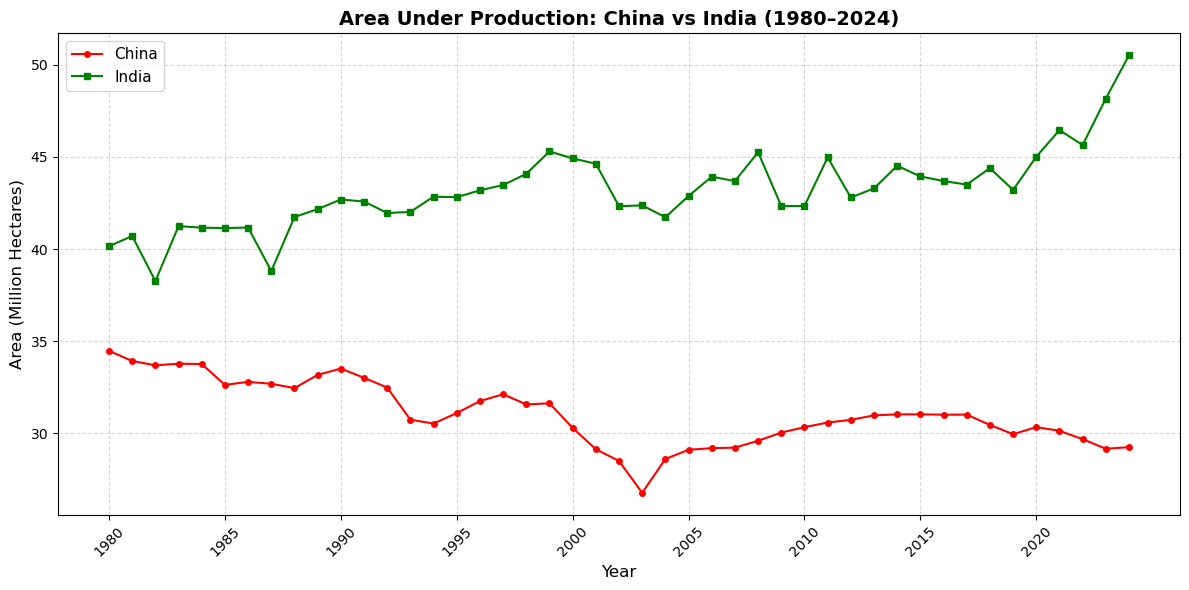

In [43]:
import matplotlib.pyplot as plt

plot_df = df_pivot[(df_pivot['Country'].isin(['China', 'India'])) & (df_pivot.index >= 1980)]

china = plot_df[plot_df['Country'] == 'China']
india = plot_df[plot_df['Country'] == 'India']

plt.figure(figsize=(12, 6))
plt.plot(china.index, china['Area'], marker='o', markersize=4, label='China', color='red')
plt.plot(india.index, india['Area'], marker='s', markersize=4, label='India', color='green')

plt.title('Area Under Production: China vs India (1980–2024)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Area (Million Hectares)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(range(1980, 2025, 5), rotation=45)
plt.tight_layout()
plt.savefig('area_china_india.png', dpi=150)
plt.show()

### Time series Analysis

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

# ── Load and clean ────────────────────────────────────────────────────────────
df = pd.read_excel('Yearly_csv.xlsx')

# Drop Area and Yield, keep only Production
df = df.drop(columns=['Area', 'Yield'])

# Convert to time series with Year as DatetimeIndex
df['Year'] = pd.to_datetime(df['Year'], format='%Y')
ts = df.set_index('Year')['Production']

rolling_mean = ts.rolling(window=5).mean()
rolling_std  = ts.rolling(window=5).std()
ts_diff      = ts.diff().dropna()


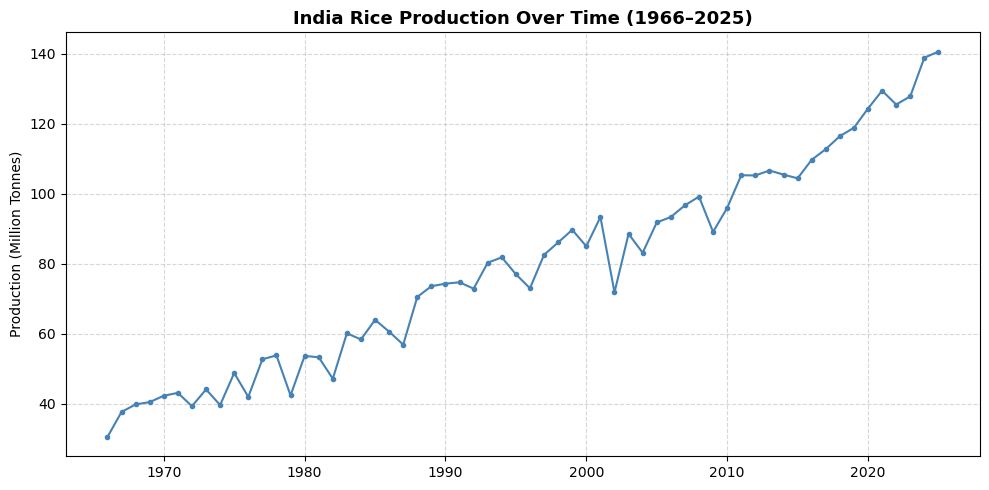

In [59]:

# ── Plot 1: Basic Time Series ─────────────────────────────────────────────────
plt.figure(figsize=(10, 5))
plt.plot(ts, color='steelblue', marker='o', markersize=3)
plt.title('India Rice Production Over Time (1966–2025)', fontsize=13, fontweight='bold')
plt.ylabel('Production (Million Tonnes)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('plot1_basic_ts.png', dpi=150)
plt.show()

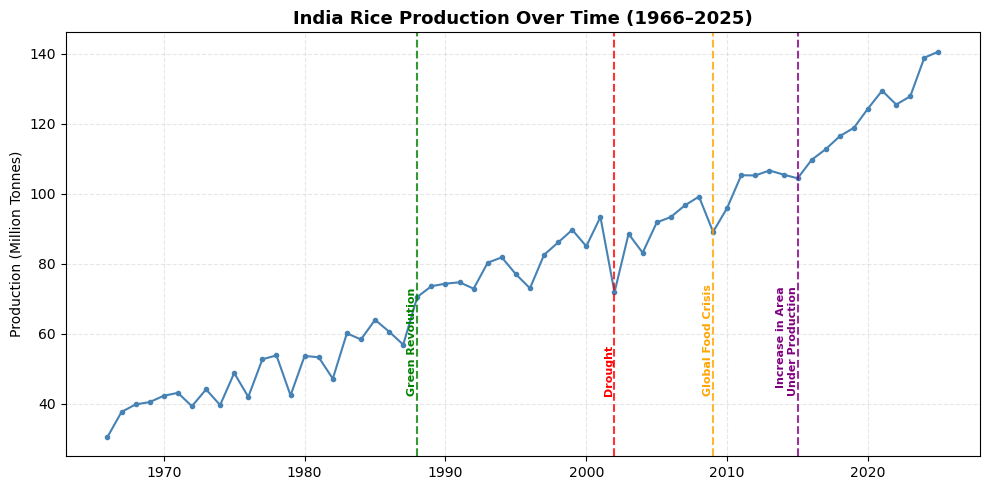

In [61]:
plt.figure(figsize=(10, 5))
plt.plot(ts, color='steelblue', marker='o', markersize=3)

# ── Structural Breaks ─────────────────────────────────────────────────────────
breaks = {
    1988: ('Green Revolution',          'green'),
    2002: ('Drought',    'red'),
    2009: ('Global Food Crisis',        'orange'),
    2015: ('Increase in Area\nUnder Production', 'purple'),
}

for year, (label, color) in breaks.items():
    plt.axvline(x=pd.Timestamp(str(year)), color=color, linestyle='--', linewidth=1.5, alpha=0.8)
    plt.text(pd.Timestamp(str(year)), ts.max() * 0.30, label,
             rotation=90, fontsize=8, color=color, fontweight='bold',
             va='bottom', ha='right')

plt.title('India Rice Production Over Time (1966–2025)', fontsize=13, fontweight='bold')
plt.ylabel('Production (Million Tonnes)')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('plot11_basic_ts.png', dpi=150)
plt.show()

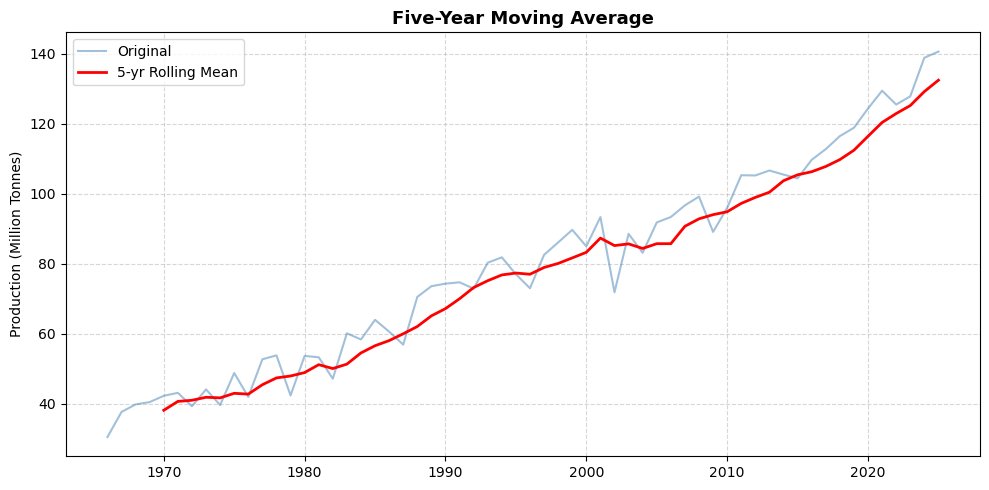

In [63]:
# ── Plot 2: Rolling Mean & Std ────────────────────────────────────────────────
plt.figure(figsize=(10, 5))
plt.plot(ts,           color='steelblue', alpha=0.5, label='Original')
plt.plot(rolling_mean, color='red',       linewidth=2, label='5-yr Rolling Mean')
plt.title('Five-Year Moving Average', fontsize=13, fontweight='bold')
plt.ylabel('Production (Million Tonnes)')
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('plot2_rolling.png', dpi=150)
plt.show()

In [171]:
from statsmodels.tsa.stattools import adfuller

# Original series
result = adfuller(ts)
print("ADF Test — Original Production")
print(f"  ADF Statistic : {result[0]:.4f}")
print(f"  p-value       : {result[1]:.4f}")
for k, v in result[4].items():
    print(f"  Critical Value {k}: {v:.4f}")
print("  ✅ STATIONARY" if result[1] <= 0.05 else "  ❌ NON-STATIONARY")

# First differenced series
result_diff = adfuller(ts_diff)
print("\nADF Test — First Differenced Production")
print(f"  ADF Statistic : {result_diff[0]:.4f}")
print(f"  p-value       : {result_diff[1]:.4f}")
for k, v in result_diff[4].items():
    print(f"  Critical Value {k}: {v:.4f}")
print("  ✅ STATIONARY" if result_diff[1] <= 0.05 else "  ❌ NON-STATIONARY")

ADF Test — Original Production
  ADF Statistic : 1.7086
  p-value       : 0.9981
  Critical Value 1%: -3.5553
  Critical Value 5%: -2.9157
  Critical Value 10%: -2.5957
  ❌ NON-STATIONARY

ADF Test — First Differenced Production
  ADF Statistic : -5.8979
  p-value       : 0.0000
  Critical Value 1%: -3.5553
  Critical Value 5%: -2.9157
  Critical Value 10%: -2.5957
  ✅ STATIONARY


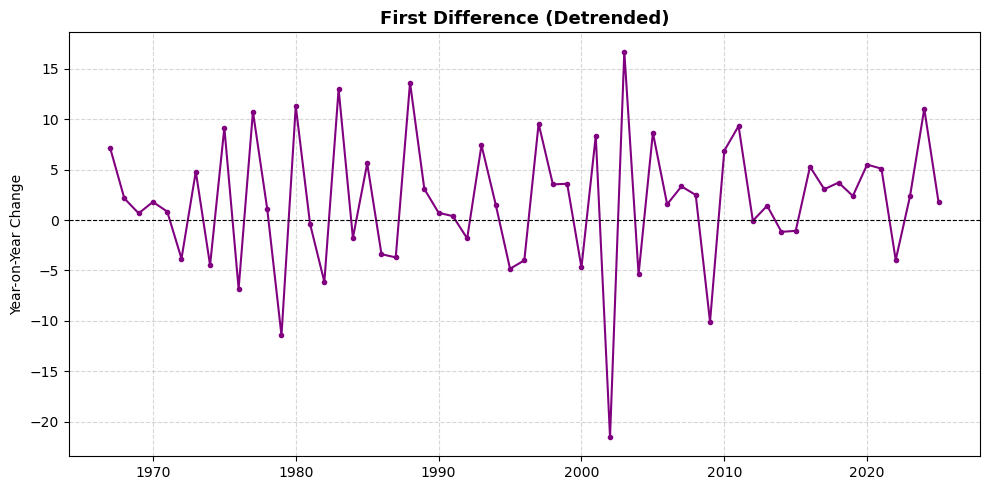

In [165]:
plt.figure(figsize=(10, 5))
plt.plot(ts_diff, color='purple', marker='o', markersize=3)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('First Difference (Detrended)', fontsize=13, fontweight='bold')
plt.ylabel('Year-on-Year Change')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('plot3_diff.png', dpi=150)
plt.show()

In [173]:
from statsmodels.tsa.stattools import kpss

# KPSS Test — Original
result = kpss(ts, regression='c', nlags='auto')
print("KPSS Test — Original Production")
print(f"  KPSS Statistic : {result[0]:.4f}")
print(f"  p-value        : {result[1]:.4f}")
for k, v in result[3].items():
    print(f"  Critical Value {k}: {v:.4f}")
print("  ❌ NON-STATIONARY" if result[1] <= 0.05 else "  ✅ STATIONARY")

# KPSS Test — First Differenced
result_diff = kpss(ts_diff, regression='c', nlags='auto')
print("\nKPSS Test — First Differenced Production")
print(f"  KPSS Statistic : {result_diff[0]:.4f}")
print(f"  p-value        : {result_diff[1]:.4f}")
for k, v in result_diff[3].items():
    print(f"  Critical Value {k}: {v:.4f}")
print("  ❌ NON-STATIONARY" if result_diff[1] <= 0.05 else "  ✅ STATIONARY")

KPSS Test — Original Production
  KPSS Statistic : 1.2904
  p-value        : 0.0100
  Critical Value 10%: 0.3470
  Critical Value 5%: 0.4630
  Critical Value 2.5%: 0.5740
  Critical Value 1%: 0.7390
  ❌ NON-STATIONARY

KPSS Test — First Differenced Production
  KPSS Statistic : 0.1810
  p-value        : 0.1000
  Critical Value 10%: 0.3470
  Critical Value 5%: 0.4630
  Critical Value 2.5%: 0.5740
  Critical Value 1%: 0.7390
  ✅ STATIONARY


C:\Users\SIDHARTH\AppData\Local\Temp\ipykernel_23364\2704660451.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(ts, regression='c', nlags='auto')
C:\Users\SIDHARTH\AppData\Local\Temp\ipykernel_23364\2704660451.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result_diff = kpss(ts_diff, regression='c', nlags='auto')


In [175]:
pip install pmdarima


   ---------------------------------------- 0.0/715.6 kB ? eta -:--:--
   ----------------------------- ---------- 524.3/715.6 kB 4.2 MB/s eta 0:00:01
   ---------------------------------------- 715.6/715.6 kB 2.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.8 MB ? eta -:--:--
   ------------------- -------------------- 1.3/2.8 MB 3.5 MB/s eta 0:00:01
   ------------------------------ --------- 2.1/2.8 MB 3.6 MB/s eta 0:00:01
   ---------------------------------------- 2.8/2.8 MB 3.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.5 MB 3.7 MB/s eta 0:00:03
   ------ --------------------------------- 1.6/9.5 MB 3.6 MB/s eta 0:00:03
   --------- ------------------------------ 2.4/9.5 MB 3.6 MB/s eta 0:00:02
   ------------- -------------------------- 3.1/9.5 MB 3.6 MB/s eta 0:00:02
   --------------- ----------

In [5]:
import pmdarima as pm

model = pm.auto_arima(
    ts,
    start_p=0, start_q=0,
    max_p=5,   max_q=5,
    d=None,              # auto-detects differencing order using ADF/KPSS
    seasonal=False,
    stepwise=True,       # Hyndman-Khandakar stepwise algorithm
    information_criterion='aic'    
)

print(model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   60
Model:               SARIMAX(0, 1, 1)   Log Likelihood                -183.016
Date:                Fri, 20 Mar 2026   AIC                            372.031
Time:                        19:44:43   BIC                            378.264
Sample:                    01-01-1966   HQIC                           374.464
                         - 01-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      1.7441      0.281      6.211      0.000       1.194       2.295
ma.L1         -0.6852      0.133     -5.156      0.000      -0.946      -0.425
sigma2        28.6541      4.610      6.216      0.0

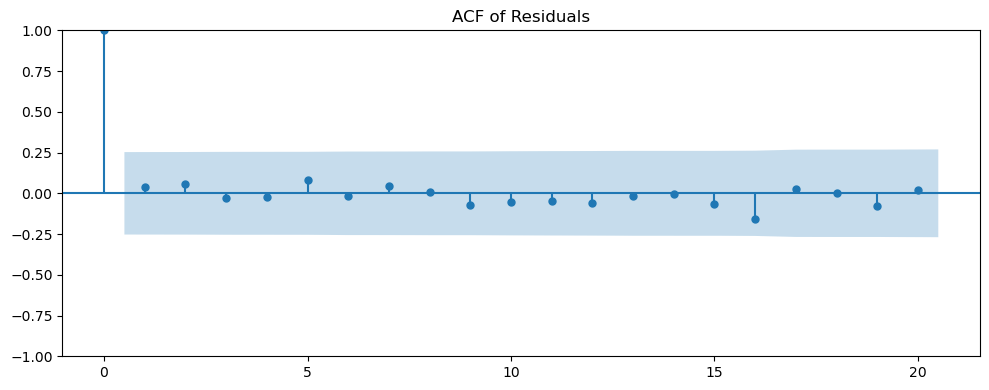

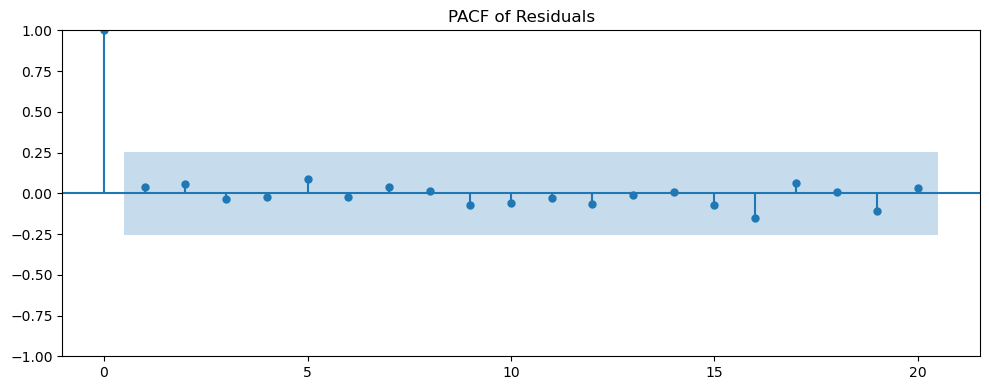

In [7]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

residuals = model.resid()

# ACF
plt.figure(figsize=(10, 4))
plot_acf(residuals, lags=20, ax=plt.gca())
plt.title('ACF of Residuals')
plt.tight_layout()
plt.show()

# PACF
plt.figure(figsize=(10, 4))
plot_pacf(residuals, lags=20, ax=plt.gca())
plt.title('PACF of Residuals')
plt.tight_layout()
plt.show()

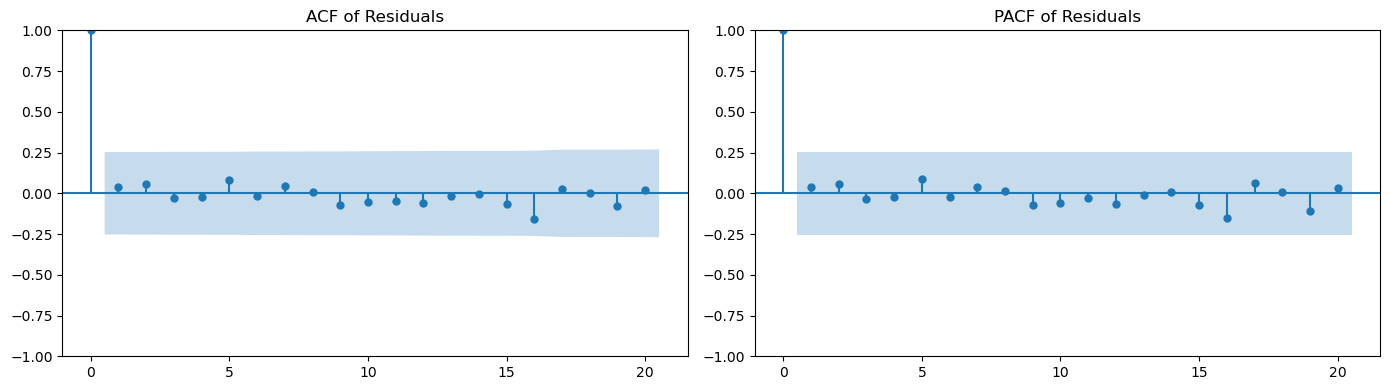

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(residuals,  lags=20, ax=axes[0])
axes[0].set_title('ACF of Residuals')

plot_pacf(residuals, lags=20, ax=axes[1])
axes[1].set_title('PACF of Residuals')

plt.tight_layout()
plt.savefig('acf_pacf_residuals.png', dpi=150)
plt.show()

Train: 1966 – 2013 (48 obs)
Test : 2014 – 2025 (12 obs)
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=321.772, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=307.478, Time=0.19 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.16 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=322.154, Time=0.02 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=306.477, Time=0.09 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=307.105, Time=0.11 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.29 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.18 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.30 sec
 ARIMA(2,1,0)(0,0,0)[0]             : AIC=313.982, Time=0.04 sec

Best model:  ARIMA(2,1,0)(0,0,0)[0] intercept
Total fit time: 1.432 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   48
Model:               SARIMAX(2, 

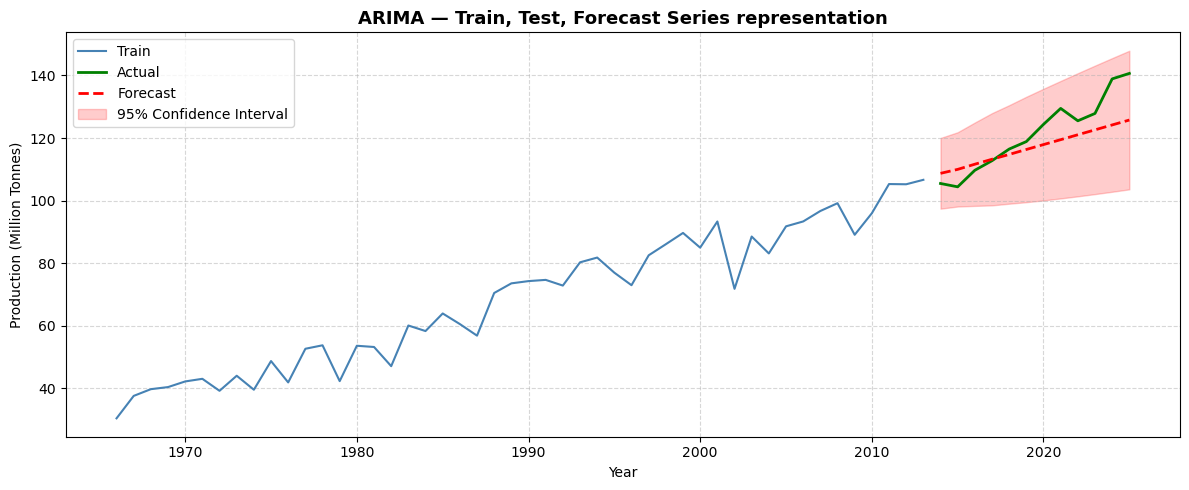

In [69]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# ── Train / Test Split (80/20) ────────────────────────────────────────────────
split = int(len(ts) * 0.80)
train = ts[:split]
test  = ts[split:]

print(f"Train: {train.index[0].year} – {train.index[-1].year} ({len(train)} obs)")
print(f"Test : {test.index[0].year} – {test.index[-1].year} ({len(test)} obs)")

# ── Fit auto_arima on train only ──────────────────────────────────────────────
model = pm.auto_arima(
    train,
    start_p=0, start_q=0,
    max_p=5,   max_q=5,
    d=None,
    seasonal=False,
    stepwise=True,
    information_criterion='aic',
    test='kpss',
    trace=True,
    error_action='ignore',
    suppress_warnings=True
)

print(model.summary())

# ── Forecast on test period ───────────────────────────────────────────────────
forecast, conf_int = model.predict(n_periods=len(test), return_conf_int=True)
forecast_series    = pd.Series(forecast, index=test.index)
conf_df            = pd.DataFrame(conf_int, index=test.index, columns=['lower', 'upper'])

# ── Evaluation Metrics ────────────────────────────────────────────────────────
mae  = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = (np.abs((test.values - forecast) / test.values).mean()) * 100

print(f"\nMAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"MAPE : {mape:.2f}%")

# ── Plot ──────────────────────────────────────────────────────────────────────
plt.figure(figsize=(12, 5))
plt.plot(train,           label='Train',    color='steelblue')
plt.plot(test,            label='Actual',   color='green',  linewidth=2)
plt.plot(forecast_series, label='Forecast', color='red',    linestyle='--', linewidth=2)
plt.fill_between(conf_df.index, conf_df['lower'], conf_df['upper'],
                 alpha=0.2, color='red', label='95% Confidence Interval')

plt.title('ARIMA — Train, Test, Forecast Series representation', fontsize=13, fontweight='bold')
plt.ylabel('Production (Million Tonnes)')
plt.xlabel('Year')
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('train_test_forecast.png', dpi=150)
plt.show()

In [11]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ── Training fitted values ────────────────────────────────────────────────────
train_fitted = pd.Series(model.predict_in_sample(), index=train.index)

# ── Test forecast ─────────────────────────────────────────────────────────────
test_forecast = pd.Series(model.predict(n_periods=len(test)), index=test.index)

# ── Metrics function ──────────────────────────────────────────────────────────
def print_metrics(actual, predicted, label):
    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual.values - predicted.values) / actual.values)) * 100
    mse  = mean_squared_error(actual, predicted)
    ss_res = np.sum((actual.values - predicted.values) ** 2)
    ss_tot = np.sum((actual.values - actual.mean()) ** 2)
    r2   = 1 - (ss_res / ss_tot)

    print(f"\n{'='*45}")
    print(f"  Error Metrics — {label}")
    print(f"{'='*45}")
    print(f"  MAE  (Mean Absolute Error)       : {mae:.4f}")
    print(f"  MSE  (Mean Squared Error)         : {mse:.4f}")
    print(f"  RMSE (Root Mean Squared Error)    : {rmse:.4f}")
    print(f"  MAPE (Mean Abs Percentage Error)  : {mape:.2f}%")
    print(f"  R²   (Coefficient of Determination): {r2:.4f}")

print_metrics(train, train_fitted, 'Training Data')
print_metrics(test,  test_forecast, 'Testing Data')



  Error Metrics — Training Data
  MAE  (Mean Absolute Error)       : 5.1219
  MSE  (Mean Squared Error)         : 50.1131
  RMSE (Root Mean Squared Error)    : 7.0791
  MAPE (Mean Abs Percentage Error)  : 9.07%
  R²   (Coefficient of Determination): 0.8928

  Error Metrics — Testing Data
  MAE  (Mean Absolute Error)       : 5.9352
  MSE  (Mean Squared Error)         : 56.8424
  RMSE (Root Mean Squared Error)    : 7.5394
  MAPE (Mean Abs Percentage Error)  : 4.66%
  R²   (Coefficient of Determination): 0.5719


In [13]:
# ── Forecast 3 years ahead ────────────────────────────────────────────────────
forecast_steps = 3 

forecast_vals, conf_int = model.predict(n_periods=forecast_steps, return_conf_int=True)

# ── Build forecast index (next 3 years after last observation) ────────────────
last_year      = ts.index[-1].year
forecast_index = pd.date_range(start=f'{last_year + 1}', periods=forecast_steps, freq='YS')

# ── Create DataFrame ──────────────────────────────────────────────────────────
forecast_df = pd.DataFrame({
    'Year'            : forecast_index.year,
    'Forecast'        : forecast_vals.round(3),
    'Lower_CI (2.5%)' : conf_int[:, 0].round(3),
    'Upper_CI (97.5%)': conf_int[:, 1].round(3)
})

forecast_df = forecast_df.set_index('Year')

print(forecast_df)


      Forecast  Lower_CI (2.5%)  Upper_CI (97.5%)
Year                                             
2026   108.723           97.429           120.016
2027   109.987           98.118           121.856
2028   111.638           98.319           124.956
